# **A/B тест двух кампаний для одного продукта**

В процессе A/B-тестирования пользователям случайным образом показываются две разные версии рекламы для одного и того же продукта. Участники контрольной группы взаимодействуют с исходной (базовой) версией, тогда как участники тестовой группы — с изменённой версией продукта.

Цель тестирования — определить, влияет ли новая версия на поведение пользователей, например, увеличивает ли она количество кликов или просмотров по сравнению с оригиналом.

**ГИПОТЕЗА H₀:** Изменение свойств рекламы не влияет на поведение пользователей.

**УСЛОВИЕ:**

**В течение месяца проведено две кампании (два датасета):**

```
control        : Контрольная кампания  (30 человек)
test           : Тестовая кампания     (30 человек)
```

 В тесте изменились свойства рекламы.

**Метрики и результат исследования**
```
Метрика                         Интерпритация                                    Результат

Основные:
- CTR (Click-through rate)      Доля кликов от общего числа показов           Вырос в 2 раза

Прокси метрики:
- Website Clicks                Количество переходов на сайт (клики по рекламе)  Не изменилось
- Impressions                   Общее количество показов рекламы                 Уменьшилось на 33%
- Add to Cart Rate              Конверсия из просмотра в корзину                 Уменьшилась на 34%
- CPC                           Стоимость одного клика                           Не изменилась
- CPATC (Cost Per Add to Cart)  Стоимость одного добавления в корзину            Увеличилось на 90%
```

**КРАТКИЕ ВЫВОДЫ**

Качество рекламного креатива улучшилось.

Эффективность рекламы повысилась без увеличения затрат.

Однако, просмотр контента и добавление в корзину снизились и стали меньше, чем в контрольной группе.

Тестовая группа лучше на верхних этапах воронки, но хуже в середине.

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.

Рекомендации:

- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).

**Содержание набора данных:**

```
Campaign Name  : Название кампании
Date           : Дата записи
Spend [USD]    : Сумма, потраченная на кампанию в долларах
Impressions    : Количество показов объявления в ходе кампании
Reach          : Количество уникальных показов рекламы
Website Clicks : Количество кликов на веб-сайте, полученных через рекламу
Searches       : Количество пользователей, выполнивших поиск на сайте
View Content   : Количество пользователей, просмотревших контент и продукты на сайте
Add to Cart    : Количество пользователей, которые добавили продукты в корзину
Purchase       : Количество покупок
```

## **Загрузка и предобработка данных**

In [ ]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, shapiro, mannwhitneyu

In [ ]:
test = pd.read_csv('/content/test_group.csv', sep=';')
control = pd.read_csv('/content/control_group.csv', sep=';')

In [ ]:
df = pd.concat([control, test], ignore_index=True)

In [ ]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# переименуем название столбцов
df = df.rename(columns={'Campaign Name': 'name', 'Date': 'date', 'Spend [USD]': 'spend', '# of Impressions': 'impressions',
                        'Reach': 'reach', '# of Website Clicks': 'clicks', '# of Searches': 'searches',
                        '# of View Content': 'view_cont', '# of Add to Cart': 'add_to_card', '# of Purchase': 'purchase'})

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y') # преобразование формата данных в дату

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   name         60 non-null     object        
 1   date         60 non-null     datetime64[ns]
 2   spend        60 non-null     int64         
 3   impressions  59 non-null     float64       
 4   reach        59 non-null     float64       
 5   clicks       59 non-null     float64       
 6   searches     59 non-null     float64       
 7   view_cont    59 non-null     float64       
 8   add_to_card  59 non-null     float64       
 9   purchase     59 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 4.8+ KB


In [ ]:
df.head(8)

,name,date,spend,impressions,reach,clicks,searches,view_cont,add_to_card,purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0
6,Control Campaign,2019-08-07,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0
7,Control Campaign,2019-08-08,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0


В данных присутствуют пропущенные значения в одной строке: практически все показатели отсутствуют за 5 августа 2019 года в контрольной группе. Поскольку данные представлены по дням и один пропущенный день может исказить анализ, его не следует игнорировать. **Удалим строку с пропущенными значениями из "Test", а также удалим из "Control" строку с такой же датой**

In [ ]:
# удалим пропущенные значения для 5 августа в тесте и в контроле
df = df[df['date'] != '2019-08-05']

**ВЫВОД**

В ходе проверики данных обнаружен пропуск в одной строке в контрольной группы. Строку удалили, также удалили строку с той же датой в тесте, чтобы не искажать картину тестирования.

Данные предобработаны и готовы к анализу

## **Анализ и проверка гипотез.**

Определим метрики:
```
Метрика                         Расчёт                                Интерпритация

Основные:
- CTR (Click-through rate)      clicks / impressions                  Доля кликов от общего числа показов

Прокси метрики:
- Website Clicks                clics                                 Количество переходов на сайт (клики по рекламе)
- Impressions                   impressions                           Общее количество показов рекламы
- Add to Cart Rate              add_to_cart / view_content            Конверсия из просмотра в корзину
- CPC                           spend / clics                         Стоимость одного клика
- CPATC (Cost Per Add to Cart)  spend / Add to Cart                   Стоимость одного добавления в корзину.
```

### **CTR (Click-through rate)** - Доля кликов от общего числа показов

H₀: CTR не изменится

In [ ]:
df['ctr'] = df['clicks'] / df['impressions']

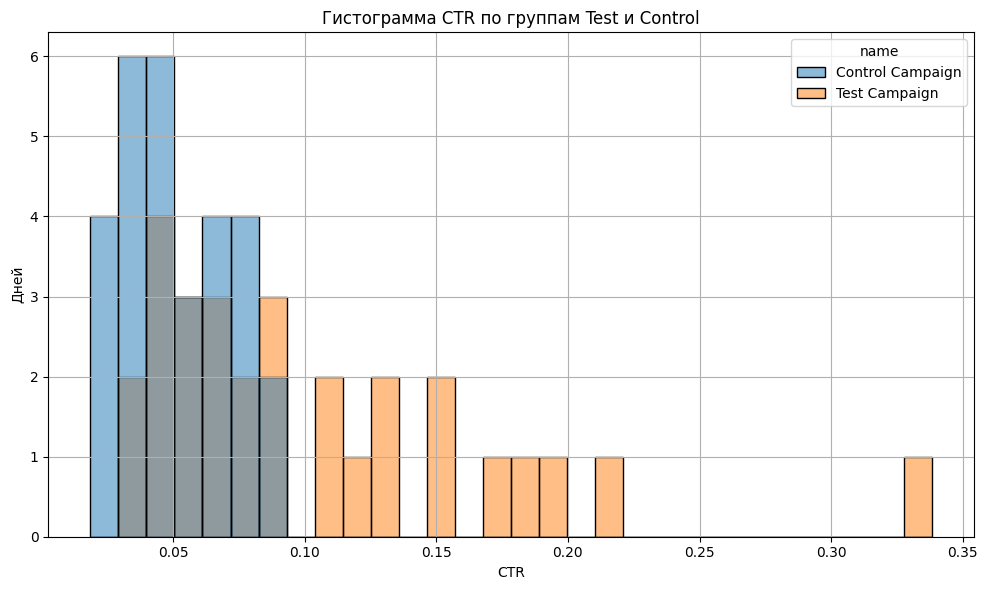

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='ctr', hue='name', bins=30)

plt.title('Гистограмма CTR по группам Test и Control')
plt.xlabel('CTR')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

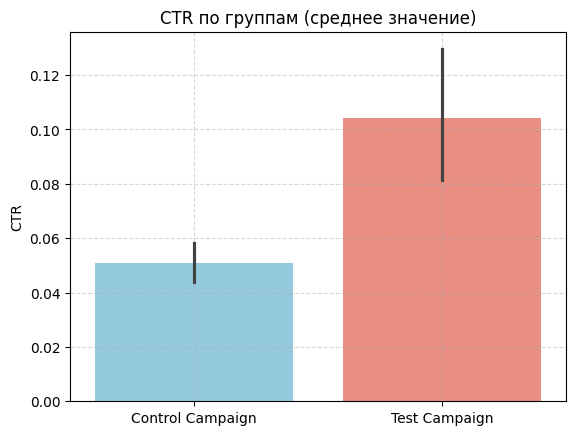

In [ ]:
palette = {'Control Campaign': 'skyblue', 'Test Campaign': 'salmon'}
sns.barplot(data=df, x='name', y='ctr', palette=palette, hue='name')
plt.title('CTR по группам (среднее значение)')
plt.xlabel('')
plt.ylabel('CTR')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
df.groupby('name')['ctr'].mean().reset_index().round(2)

,name,ctr
0,Control Campaign,0.05
1,Test Campaign,0.10


In [ ]:
control = df[df['name'] == 'Control Campaign']['ctr']
test = df[df['name'] == 'Test Campaign']['ctr']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на 104.5 %


Доля кликов по рекламе выросла в 2 раза.

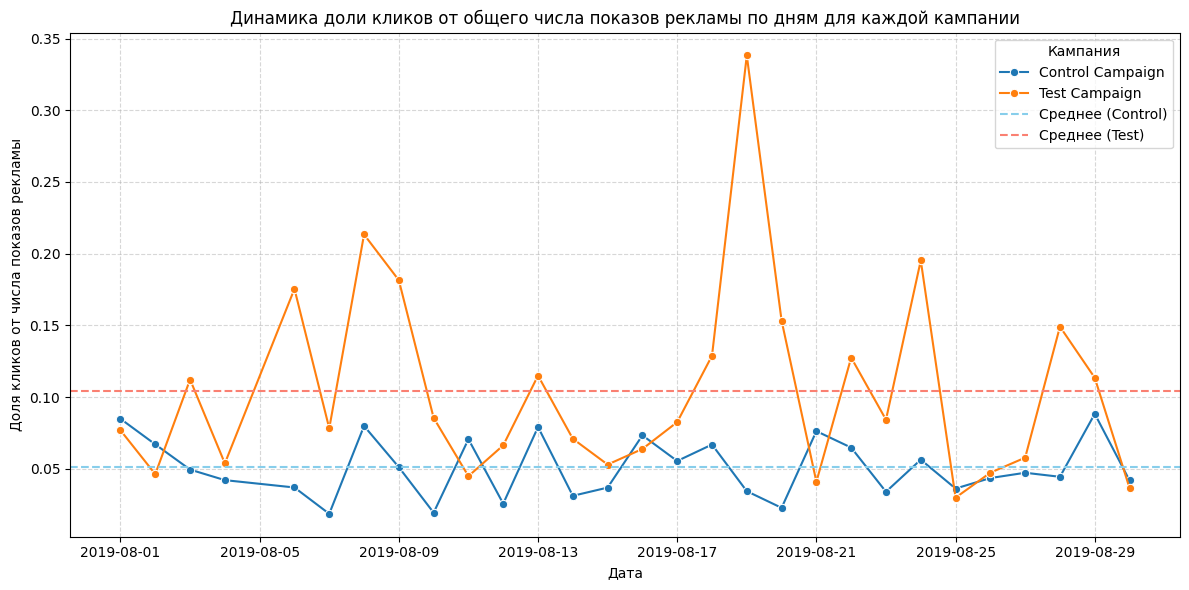

In [ ]:
# Строим график
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='ctr', hue='name', marker='o')

plt.axhline(mean_control, color='skyblue', linestyle='--', linewidth=1.5, label='Среднее (Control)')
plt.axhline(mean_test, color='salmon', linestyle='--', linewidth=1.5, label='Среднее (Test)')

plt.title('Динамика доли кликов от общего числа показов рекламы по дням для каждой кампании')
plt.xlabel('Дата')
plt.ylabel('Доля кликов от числа показов рекламы')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Кампания')
plt.tight_layout()
plt.show()

In [ ]:
# Проверим распределение на нормальность
stat, p = shapiro(test)
if p<0.05:
  print(f'Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f}. Распределение не является нормальным.')
else:
  print(f'Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f}. Распределение является нормальным.')

Shapiro-Wilk test: stat=0.8493, p=0.0007. Распределение не является нормальным.


В связи с тем, что выборка небольшая и распределение показателя CTR ненормальное, для  оценки используем Mann–Whitney U-тест.

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value<0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 660.0, p_value = 0.0002.
p_value < 0.05. Отвергаем нулевую гепотезу.


Прверим гипотезу, используя бутстрап

In [ ]:
# Задаем число итераций бутстрапа
n_iterations = 10000
boot_diffs = []

# Приводим к массивам
control = df[df['name'] == 'Control Campaign']['ctr'].values
test = df[df['name'] == 'Test Campaign']['ctr'].values

# Бутстрап: 10 000 раз случайно выбираем значения с возвращением и считаем разницу средних
for _ in range(n_iterations):
    boot_control = np.random.choice(control, size=len(control), replace=True)
    boot_test = np.random.choice(test, size=len(test), replace=True)

    diff = boot_test.mean() - boot_control.mean()
    boot_diffs.append(diff)

# 95% доверительный интервал
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
mean_diff = np.mean(boot_diffs)

print(f'Средняя разница CTR (тест - контроль): {mean_diff:.4f}')
print(f'95% доверительный интервал: ({ci_lower:.4f}, {ci_upper:.4f})')

# Проверка, содержит ли ноль
if ci_lower > 0 or ci_upper < 0:
    print("Доверительный интервал не содержит 0 — есть статистически значимая разница.")
else:
    print("Интервал содержит 0 — статистическая значимость не подтверждена.")

Средняя разница CTR (тест - контроль): 0.0533
95% доверительный интервал: (0.0290, 0.0795)
Доверительный интервал не содержит 0 — есть статистически значимая разница.


Проверим минимально значимый эффект

In [ ]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05  # уровень значимости
power = 0.8   # желаемая мощность
n = min(len(control), len(test))  # размер группы

# Расчёт объединённого стандартного отклонения
std_pooled = np.sqrt((np.var(control, ddof=1) + np.var(test, ddof=1)) / 2)

# Расчёт минимального effect size
analysis = TTestIndPower()
effect_size = analysis.solve_power(nobs1=n, alpha=alpha, power=power, alternative='two-sided')

# Перевод стандартизированного эффекта в абсолютную разницу
mde = effect_size * std_pooled
print(f"Минимально значимый эффект (MDE) по CTR: {mde:.4f}")

diff = abs(df.query('name == "Control Campaign"')['ctr'].mean() - df.query('name == "Test Campaign"')['ctr'].mean())
if mde < diff:
  print('Изменения превышают MDE, т.е. тест имеет достаточную мощность')
else:
  print('Изменения не превышают MDE, т.е. тест имеет недостаточную мощность')

Минимально значимый эффект (MDE) по CTR: 0.0377
Изменения превышают MDE, т.е. тест имеет достаточную мощность


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: CTR не изменится.

Анализ показал, что доля кликов увеличилась в 2 раза.

Изменения превышают значимый эффект MDE.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 660.0, p = 0.0002. **H₀ отвергаем.**

Результаты теста подтверждаются с использованием бутстрапа.

**ИТОГ**

В тестовой группе доля кликов из рекламы критически изменилась (увеличилась в 2 раза)

###**Clicks** - количество кликов из рекламы

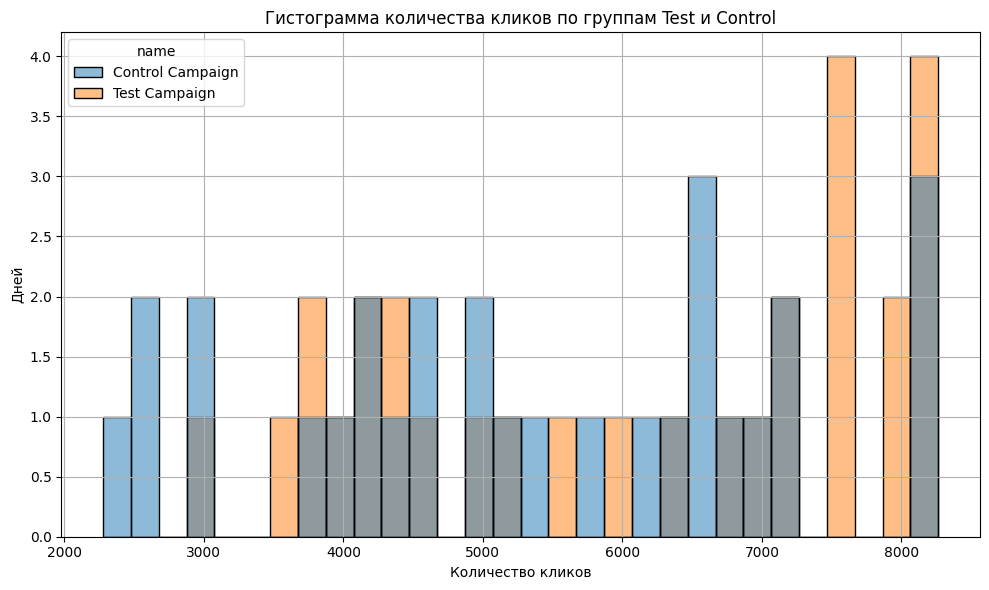

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='clicks', hue='name', bins=30)

plt.title('Гистограмма количества кликов по группам Test и Control')
plt.xlabel('Количество кликов')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

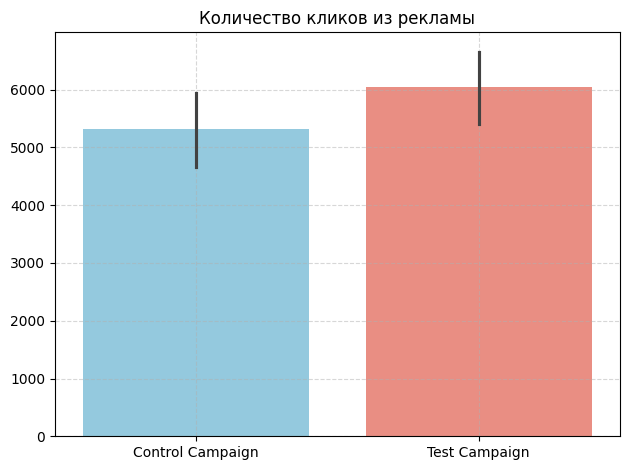

In [ ]:
# График Количество кликов с рекламы по кампаниям
#plt.figure(figsize=(5,4))
sns.barplot(x='name', y='clicks', data=df, hue='name', palette=palette)
plt.title('Количество кликов из рекламы')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('name')['clicks'].mean().reset_index().round(2)

,name,clicks
0,Control Campaign,5320.79
1,Test Campaign,6038.17


In [ ]:
control = df[df['name'] == 'Control Campaign']['clicks']
test = df[df['name'] == 'Test Campaign']['clicks']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на 13.5 %


Количество кликов из рекламы увеличилось примерно на 13.5%

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value<0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 516.0, p_value = 0.1396.
p_value > 0.05. Нулевая гипотеза верна.


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: количество кликов критически не изменится.

Анализ показал, что доля кликов увеличилась в на 15%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 516.0, p = 0.1396 > 0.05. Это говорит о том, что **H₀ верна.**

**ИТОГ**

В тестовой группе количество кликов из рекламы критически НЕ изменилась.

### **Impressions** - количество показов рекламы

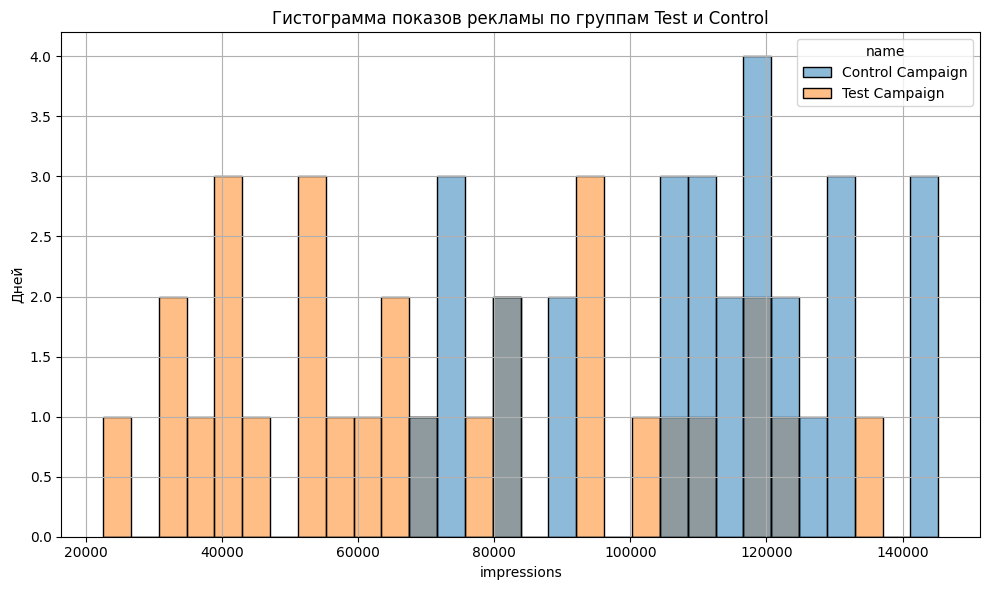

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='impressions', hue='name', bins=30)

plt.title('Гистограмма показов рекламы по группам Test и Control')
plt.xlabel('impressions')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

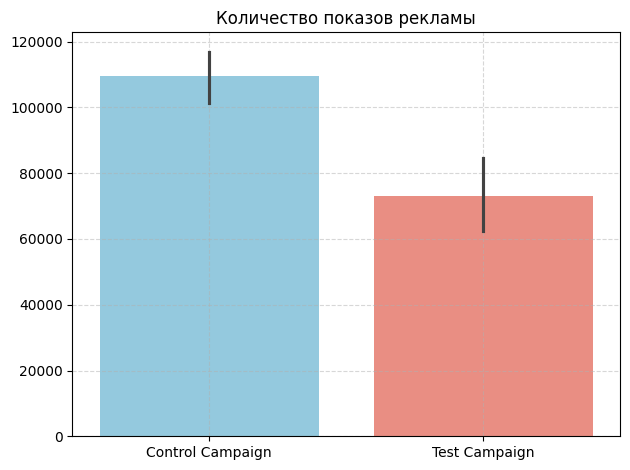

In [ ]:
# График Количество показов рекламы по кампаниям
#plt.figure(figsize=(5,4))
sns.barplot(x='name', y='impressions', data=df, hue='name', palette=palette)
plt.title('Количество показов рекламы')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('name')['impressions'].mean().reset_index().round(2)

,name,impressions
0,Control Campaign,109559.76
1,Test Campaign,73215.48


In [ ]:
control = df[df['name'] == 'Control Campaign']['impressions']
test = df[df['name'] == 'Test Campaign']['impressions']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на -33.2 %


Количество показов рекламы сократилось примерно на 33%.

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value<0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 158.0, p_value = 0.0000.
p_value < 0.05. Отвергаем нулевую гепотезу.


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: количество показов рекламы не изменится.

Анализ показал, что доля показов рекламы уменьшилось на 30%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 158.0, p = 0.0000. **H₀ отвергаем.**

**ИТОГ**

В тестовой группе количество показов рекламы критически изменилась (уменьшилось примерно на 30%)

###**Add to Cart Rate** - Конверсия из просмотра в корзину

In [ ]:
df['card_rate'] = df['add_to_card'] / df['view_cont']

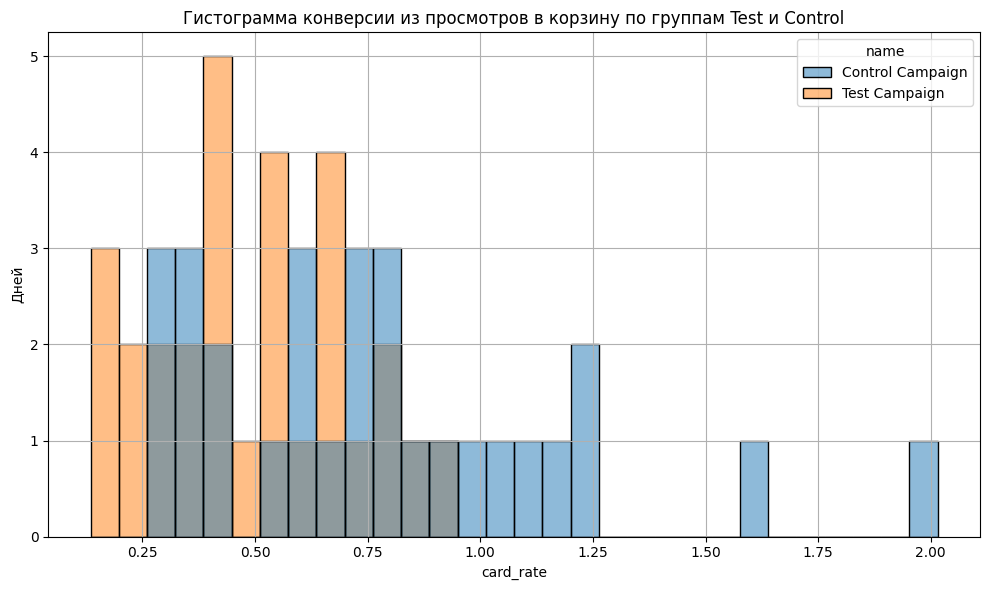

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='card_rate', hue='name', bins=30)

plt.title('Гистограмма конверсии из просмотров в корзину по группам Test и Control')
plt.xlabel('card_rate')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

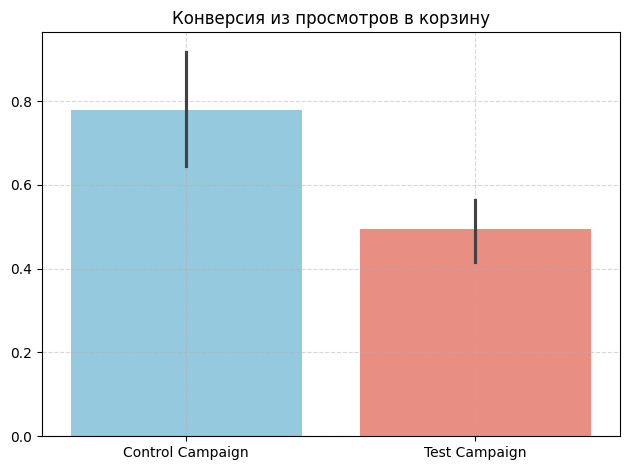

In [ ]:
# График Конверсия из просмотра рекламы в корзину
#plt.figure(figsize=(5,4))
sns.barplot(x='name', y='card_rate', data=df, hue='name', palette=palette)
plt.title('Конверсия из просмотров в корзину')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('name')['card_rate'].mean().reset_index().round(2)

,name,card_rate
0,Control Campaign,0.78
1,Test Campaign,0.49


In [ ]:
control = df[df['name'] == 'Control Campaign']['card_rate']
test = df[df['name'] == 'Test Campaign']['card_rate']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на -36.4 %


Конверсия в добавление в корзину из просмотра уменьшилась примерно на 36%

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value<0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 237.0, p_value = 0.0044.
p_value < 0.05. Отвергаем нулевую гепотезу.


В связи с тем, что p-value близко к 0.05, дополнительно проверим гипотезу с помощью бутстрапа и определим критическое изменение.

Проверка с помощью бутстрапа:

In [ ]:
# Задаем число итераций бутстрапа
n_iterations = 10000
boot_diffs = []

# Приводим к массивам
control = df[df['name'] == 'Control Campaign']['card_rate'].values
test = df[df['name'] == 'Test Campaign']['card_rate'].values

# Бутстрап: 10 000 раз случайно выбираем значения с возвращением и считаем разницу средних
for _ in range(n_iterations):
    boot_control = np.random.choice(control, size=len(control), replace=True)
    boot_test = np.random.choice(test, size=len(test), replace=True)

    diff = boot_test.mean() - boot_control.mean()
    boot_diffs.append(diff)

# 95% доверительный интервал
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
mean_diff = np.mean(boot_diffs)

print(f'Средняя разница CTR (тест - контроль): {mean_diff:.4f}')
print(f'95% доверительный интервал: ({ci_lower:.4f}, {ci_upper:.4f})')

# Проверка, содержит ли ноль
if ci_lower > 0 or ci_upper < 0:
    print("Доверительный интервал не содержит 0 — есть статистически значимая разница.")
else:
    print("Интервал содержит 0 — статистическая значимость не подтверждена.")

Средняя разница CTR (тест - контроль): -0.2853
95% доверительный интервал: (-0.4564, -0.1241)
Доверительный интервал не содержит 0 — есть статистически значимая разница.


Определение минимально значимого эффекта:

In [ ]:
from statsmodels.stats.power import TTestIndPower

alpha = 0.05  # уровень значимости
power = 0.8   # желаемая мощность
n = min(len(control), len(test))  # размер группы

# Расчёт объединённого стандартного отклонения
std_pooled = np.sqrt((np.var(control, ddof=1) + np.var(test, ddof=1)) / 2)

# Расчёт минимального effect size
analysis = TTestIndPower()
effect_size = analysis.solve_power(nobs1=n, alpha=alpha, power=power, alternative='two-sided')

# Перевод стандартизированного эффекта в абсолютную разницу
mde = effect_size * std_pooled
print(f"Минимально значимый эффект (MDE) по CTR: {mde:.4f}")

diff = abs(df.query('name == "Control Campaign"')['ctr'].mean() - df.query('name == "Test Campaign"')['ctr'].mean())
if mde < diff:
  print('Изменения превышают MDE, т.е. тест имеет достаточную мощность')
else:
  print('Изменения не превышают MDE, т.е. тест имеет недостаточную мощность')

Минимально значимый эффект (MDE) по CTR: 0.2473
Изменения не превышают MDE, т.е. тест имеет недостаточную мощность


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: конверсия из просмотра в добавление в корзину не изменится.

Анализ показал, что конверсия уменьшилось примерно на 35%.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест и дполнительно проверили при помощи бутстрапа.

В резудьтате U = 237.0, p = 0.0044. **H₀ отвергаем.**

Однако, изменения на данном тесте не превышают MDE, т.е. эксперимент имеет недостаточную мощность.

**ИТОГ**

В тестовой группе конверсия в добавление в корзину изменилась (уменьшилось примерно на 35%), однако это изменение не превышает маинимально значимый эффект.

###**CPC** - Стоимость одного клика

In [ ]:
df['cpc'] = df['spend'] / df['clicks']

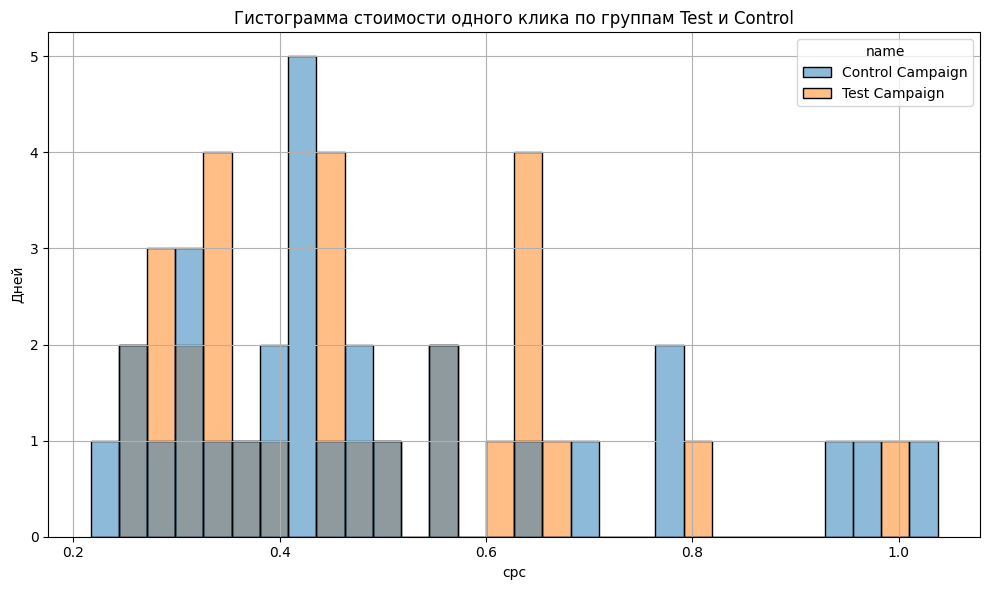

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='cpc', hue='name', bins=30)

plt.title('Гистограмма стоимости одного клика по группам Test и Control')
plt.xlabel('cpc')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

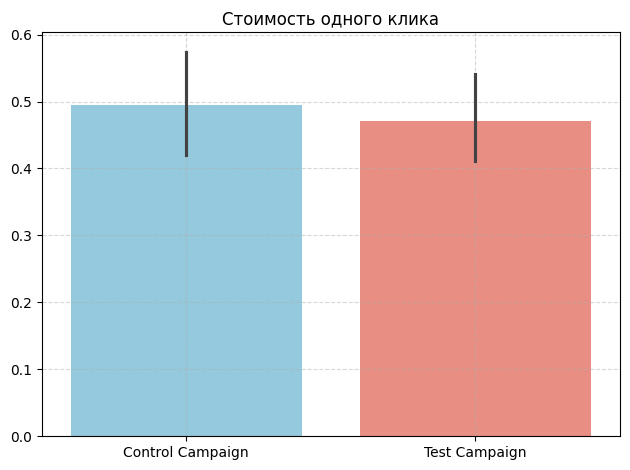

In [ ]:
# График Стоимость одного клика
#plt.figure(figsize=(5,4))
sns.barplot(x='name', y='cpc', data=df, hue='name', palette=palette)
plt.title('Стоимость одного клика')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('name')['cpc'].mean().reset_index().round(2)

,name,cpc
0,Control Campaign,0.49
1,Test Campaign,0.47


In [ ]:
control = df[df['name'] == 'Control Campaign']['cpc']
test = df[df['name'] == 'Test Campaign']['cpc']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на -4.8 %


Стоимость одного клика немного уменьшилась

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value < 0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 409.0, p_value = 0.8642.
p_value > 0.05. Нулевая гипотеза верна.


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: стоимость одного клика не меняется.

Анализ показал, что стоимость кликов уменьшилась.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 409.0, p = 0.8642 > 0.05, что говорит о том, что **H₀ верна.**

**ИТОГ**

В тестовой группе стоимость клика критически не изменилась.

###**CPATC** - стоимость одного добавления в корзину

In [ ]:
df['cpatc'] = df['spend'] / df['add_to_card']

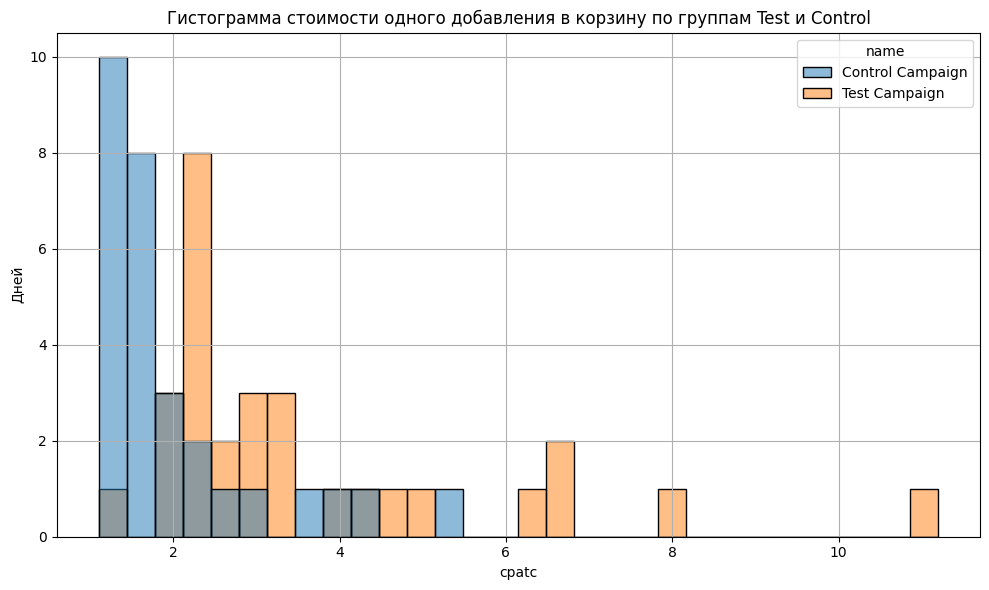

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='cpatc', hue='name', bins=30)

plt.title('Гистограмма стоимости одного добавления в корзину по группам Test и Control')
plt.xlabel('cpatc')
plt.ylabel('Дней')
plt.grid(True)
plt.tight_layout()
plt.show()

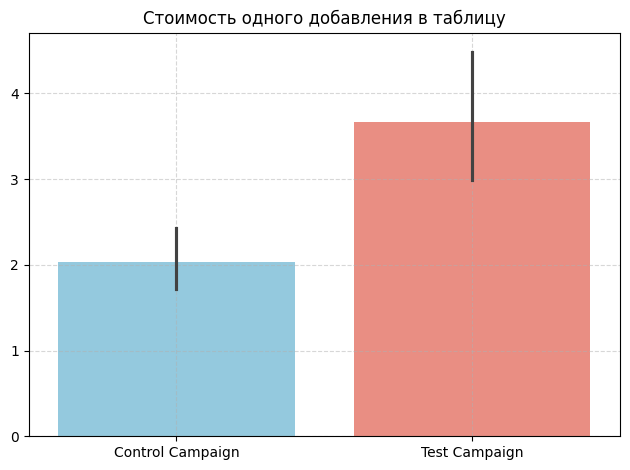

In [ ]:
# График Стоимость одного клика
#plt.figure(figsize=(5,4))
sns.barplot(x='name', y='cpatc', data=df, hue='name', palette=palette)
plt.title('Стоимость одного добавления в таблицу')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('name')['cpatc'].mean().reset_index().round(2)

,name,cpatc
0,Control Campaign,2.03
1,Test Campaign,3.67


In [ ]:
control = df[df['name'] == 'Control Campaign']['cpatc']
test = df[df['name'] == 'Test Campaign']['cpatc']
mean_control = control.mean()
mean_test = test.mean()
rel_change = ((mean_test - mean_control) / mean_control) * 100
print('Показатели теста отличаются на', rel_change.round(1), '%')

Показатели теста отличаются на 80.4 %


Стоимость одного добавления в корзину увеличилась примерно на 80%

In [ ]:
u_stat, p_value = mannwhitneyu(test, control, alternative='two-sided')
if p_value < 0.05:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value < 0.05. Отвергаем нулевую гепотезу.')
else:
  print(f'U = {u_stat}, p_value = {p_value:.4f}.')
  print('p_value > 0.05. Нулевая гипотеза верна.')

U = 697.0, p_value = 0.0000.
p_value < 0.05. Отвергаем нулевую гепотезу.


**ВЫВОД**

В данном разделе проверяли гипотезу: H₀: стоимость одного добавления в корзину не меняется.

Анализ показал, что стоимость одного добавления в корзину увеличилась.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 697.0, p = 0.0000 < 0.05. **H₀ отвергаем.**

**ИТОГ**

В тестовой группе стоимость добавления в корзину изменилась (увеличилась на 90%).

###**Воронка конверсий**

In [ ]:
# разделение
test_df = df.query('name == "Test Campaign"')
control_df = df.query('name == "Control Campaign"')

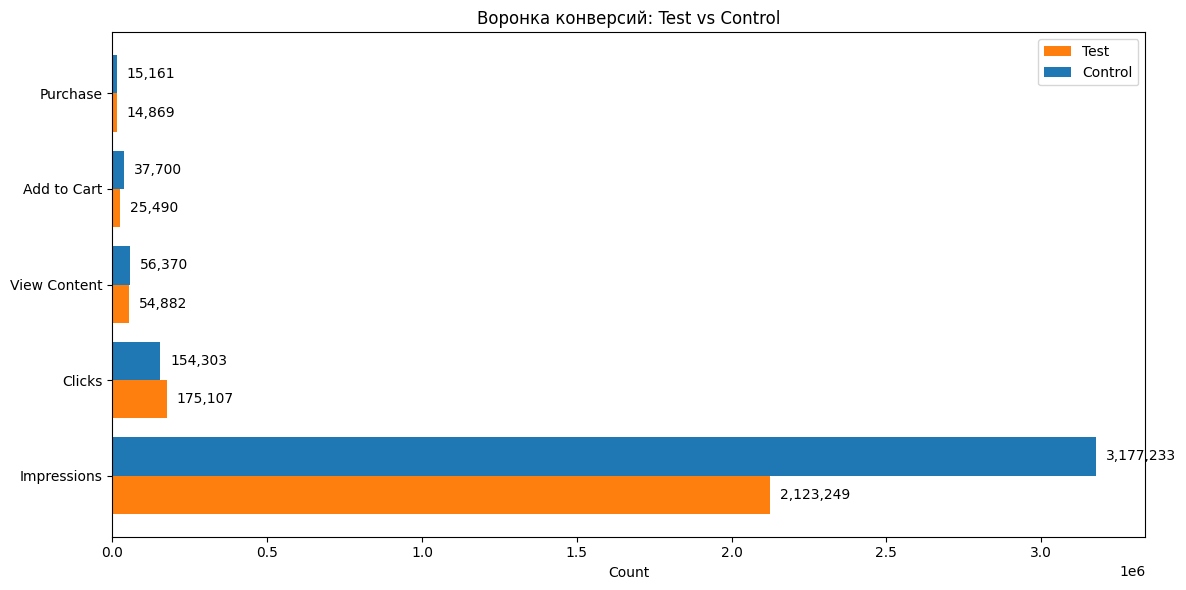

In [ ]:
def plot_combined_funnel(test_df, control_df):
    steps = ['Impressions', 'Clicks', 'View Content', 'Add to Cart', 'Purchase']
    test_values = [
        test_df['impressions'].sum(),
        test_df['clicks'].sum(),
        test_df['view_cont'].sum(),
        test_df['add_to_card'].sum(),
        test_df['purchase'].sum()
    ]
    control_values = [
        control_df['impressions'].sum(),
        control_df['clicks'].sum(),
        control_df['view_cont'].sum(),
        control_df['add_to_card'].sum(),
        control_df['purchase'].sum()
    ]

    x = range(len(steps))
    width = 0.4

    plt.figure(figsize=(12, 6))
    plt.barh([i - width/2 for i in x], test_values, height=width, label='Test', color='#ff7f0e')
    plt.barh([i + width/2 for i in x], control_values, height=width, label='Control', color='#1f77b4')

    plt.title('Воронка конверсий: Test vs Control')
    plt.yticks(x, steps)
    plt.xlabel('Count')
    plt.legend()

    # Добавляем подписи значений
    for i, (tv, cv) in enumerate(zip(test_values, control_values)):
        plt.text(tv + max(test_values + control_values)*0.01, i - width/2, f"{tv:,.0f}", va='center')
        plt.text(cv + max(test_values + control_values)*0.01, i + width/2, f"{cv:,.0f}", va='center')

    plt.tight_layout()
    plt.show()

plot_combined_funnel(test_df, control_df)

Показов рекламы в тесте гораздо меньше, при этом количество кликов из рекламы стало больше, чем в контроле.

Это говорит о том, что качество рекламного креатива улучшилось, привлечение стало работать лучше.

Из большего количества кликов в тесте просмотр контента снизился и стал меньше, чем в контрольной группе.

Снижение также наблюдается далее в добавлении в корзину и покупку.

Это значит, что несмотря на большее количество переходов, пользователи тестовой группы реже выбирают и покупают товар, т.е. тестовая кампания привлекает больше "холодных" пользователей, которые не конвертируются дальше.

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.

Рекомендации:
- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).

# **Выводы**

Метрики, где изменения значимы:
```
Metric         Изменение   Интерпретация

Основная
ctr            +102%       Вырос Click-Through Rate от показов видимо за счет рекламы.

Прокси
impressions    -33%        Показы в тестовой кампании упали.
cpatc          +80%        Стоимоть одного добавления в корзину возрасла
card_rate      -36%        В корзину добавляют реже — проблема конверсии.
```

Метрики без значимых изменений:
```
Metric         Интерпретация

clics          Хотя кликов стало больше, статистически это незначимо.
cpc            Цена за клик критически не изменилась

```

В работе учитывали размер выборки и нормальность распределений величин. Для оценки критичности изменений был выбран Mann–Whitney U-тест.

Как итог. Изменения в рекламе работают. Процент кликов из рекламы увеличился в 2 раза.

Изменение превышает значимый эффект MDE.

Ввиду того, что распределение величин ненормальное, а выборка 29 человек, для проверки гипотезы использовали  Mann–Whitney U-тест.

В резудьтате U = 660.0, p = 0.0002. **H₀ отвергаем.**

Результаты теста подтверждаются с использованием бутстрапа.

Качество рекламного креатива улучшилось.
Эффективность повысилась без увеличения затрат.

При этом стоит заметить, что конверсия в корзину на треть уменьшилась и стоимость одного добавления в корзину увеличилось на 90%. Это может говорить о том, что страница товара не соответсвует рекламе. А стоимость одной конверсии резко растёт.

**Как итог:**

Качество рекламного креатива улучшилось.

Эффективность рекламы повысилась без увеличения затрат.

Однако, просмотр контента и добавление в корзину снизились и стали меньше, чем в контрольной группе.

Тестовая группа лучше на верхних этапах воронки, но хуже в середине.

Возможные причины:

- Несоответствие ожиданий от рекламы и реального предложения на сайте (например, реклама завлекала клики, но не соответствовала контенту лендинга).

- Плохой UX сайта (сложный процесс добавления в корзину, долгая загрузка).

- Разница в аудитории (тестовая группа могла привлечь больше "случайных" кликов).

- Возможно, в тесте была более широкая, но менее релевантная аудитория.

Рекомендации:

- Проверить соответствие рекламы.

- Оптимизировать страницы продукта (упростить добавление в корзину, улучшить UI/UX).